## Dataset Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import wandb

import torch, os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.utils.prune as prune
import time

# Try attaching to GPU
device = str(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print('Using:', device)

plt.style.use('https://github.com/greydanus/mnist1d/raw/master/notebooks/mpl_style.txt')

Using: cuda


In [2]:
from mnist1d.data import get_dataset, get_dataset_args
from mnist1d.utils import set_seed, to_pickle, from_pickle

import sys ; sys.path.append('./mnist1d/notebooks')

In [3]:
args = get_dataset_args()
data = get_dataset(args=args)  # by default, this will download a pre-made dataset from the GitHub repo

print("Examples in training set: {}".format(len(data['y'])))
print("Examples in test set: {}".format(len(data['y_test'])))
print("Length of each input: {}".format(data['x'].shape[-1]))
print("Number of classes: {}".format(len(data['templates']['y'])))

File already exists. Skipping download.
Successfully loaded data from ./mnist1d_data.pkl
Examples in training set: 4000
Examples in test set: 1000
Length of each input: 40
Number of classes: 10


In [4]:
data.keys()

dict_keys(['x', 'x_test', 'y', 'y_test', 't', 'templates'])

In [5]:
# Convert to torch tensors
x_train = torch.tensor(data['x'], dtype=torch.float32)
y_train = torch.tensor(data['y'], dtype=torch.long)

x_test = torch.tensor(data['x_test'], dtype=torch.float32)
y_test = torch.tensor(data['y_test'], dtype=torch.long)

# Add channel dimension: (N, 1, 40)
x_train = x_train.unsqueeze(1)
x_test = x_test.unsqueeze(1)

train_ds = TensorDataset(x_train, y_train)
test_ds = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)


## Training And Evaluation Functions

In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [7]:
@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


In [8]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [9]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def confusion_matrix_with_plot(
    model,
    dataloader,
    class_names=None,
    device=None,
    normalize='true',      # None, 'true', 'pred', 'all'
    figsize=(8, 6),
    title="Confusion Matrix"
):
    """
    Computes and plots the confusion matrix for a classification model.

    Args:
        model (torch.nn.Module): trained model
        dataloader (DataLoader): test/validation dataloader
        class_names (list[str], optional): class labels
        device (torch.device, optional): cpu or cuda
        normalize (str or None): normalization mode
        figsize (tuple): matplotlib figure size
        title (str): plot title

    Returns:
        cm (np.ndarray): confusion matrix
    """

    model.eval()

    if device is None:
        device = next(model.parameters()).device

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            y_true.append(y.cpu())
            y_pred.append(preds.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    cm = confusion_matrix(y_true, y_pred, normalize=normalize)

    # ---- Plot ----
    plt.figure(figsize=figsize)

    fmt = ".2f" if normalize else "d"

    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.title(title)
    plt.show()

    return cm


## Knoledge Distillation

### Teacher Network

In [21]:
import torch
import torch.nn as nn

class TeacherCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1D-CNN backbone with Batch Normalization
        self.features = nn.Sequential(
            # Block 1: Input (B, 1, 40)
            nn.Conv1d(1, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2), # -> (B, 64, 20)
            nn.Dropout(0.2),

            # Block 2
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2), # -> (B, 128, 10)
            nn.Dropout(0.2),

            # Block 3
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            # Global Average Pooling ensures the model is robust to 
            # where the digit "signal" appears in the sequence.
            nn.AdaptiveAvgPool1d(1) # -> (B, 256, 1)
        )

        # Wider Classification Head for higher capacity
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 1024), 
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        # Ensure input shape is (Batch, Channels, Length)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        return self.classifier(x)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher = TeacherCNN().to(device)
teacher = TeacherCNN().to(device)
count = sum(p.numel() for p in teacher.parameters() if p.requires_grad)
print(f'Teacher CNN parameters: {count}')


Teacher CNN parameters: 999562


In [ ]:
wandb.init(
    project="mnist-1d-KDvsLTH",
    group="TeacherCNN",
    name="TeacherCNN",
    config={
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 500,
        "patience": 50,
        "architecture": "TeacherCNN",
        "scheduler": "CosineAnnealingLR"
    }
)

teacher = TeacherCNN().to(device)
optimizer = torch.optim.Adam(teacher.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=wandb.config.epochs)
criterion = nn.CrossEntropyLoss()
epochs = wandb.config.epochs
#early_stopper = EarlyStopping(patience=wandb.config.patience)

wandb.watch(teacher, log_freq=100)

best_test_acc = 0.0
model_path = "best_teacher_model.pth"

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(teacher, train_loader, optimizer, criterion)
    test_loss, test_acc = eval_epoch(teacher, test_loader, criterion)

    # Step the scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    wandb.log({
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "learning_rate": current_lr
    }, step=epoch)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(teacher.state_dict(), model_path)
        wandb.save(model_path)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Acc: {test_acc:.3f} | LR: {current_lr:.6f}")

print("\nTraining complete.")

teacher.load_state_dict(torch.load(model_path))

final_loss, final_acc = eval_epoch(teacher, test_loader, nn.CrossEntropyLoss())

wandb.log({
    "best_test_loss": final_loss,
    "best_test_acc": final_acc
})

print(f"Best Teacher model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

wandb.finish()

wandb: Currently logged in as: matteo-piras (matteo-piras-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 010 | Acc: 0.942 | LR: 0.000999
Epoch 020 | Acc: 0.970 | LR: 0.000996


KeyboardInterrupt: 

socket.send() raised exception.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7db2b5308d90>> (for post_run_cell), with arguments args (<ExecutionResult object at 7db297ec57e0, execution_count=11 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7db297ec57b0, raw_cell="wandb.init(
    project="mnist-1d-KDvsLTH",
    gr.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btargaryen.micc.unifi.it/andromeda/personal/mpiras/CV-project/notebook.ipynb#X20sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [23]:

model_path = "best_teacher_model.pth"

teacher.load_state_dict(torch.load(model_path))

final_loss, final_acc = eval_epoch(teacher, test_loader, nn.CrossEntropyLoss())

print(f"Best Teacher model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Best Teacher model - Acc: 0.9940 | Loss: 0.0284


### Student Network

In [56]:
class StudentCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1D-CNN backbone with Batch Normalization
        self.features = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 16, kernel_size=5, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            #nn.MaxPool1d(2),
            #nn.Dropout(0.1),

            # Block 2
            nn.Conv1d(16, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            #nn.MaxPool1d(2), 
            #nn.Dropout(0.1),

            # Block 3
            #nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1),
            #nn.BatchNorm1d(32),
            #nn.ReLU(),
            #nn.Dropout(0.1)
            # Global Average Pooling ensures the model is robust to 
            # where the digit "signal" appears in the sequence.
            #nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*10, 32), 
            nn.ReLU(),
            #nn.Dropout(0.2),
            #nn.Linear(64, 32),
            #nn.ReLU(),
            #nn.Dropout(0.1),
            nn.Linear(32, 10)
        )

    def forward(self, x):
        # Ensure input shape is (Batch, Channels, Length)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        return self.classifier(x)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
student = StudentCNN().to(device)
count = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f'Student CNN parameters: {count}')


Student CNN parameters: 6426


In [ ]:
import torch
import torch.nn as nn

class StudentCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        # Adjusted hidden dimension to 19
        self.classifier = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(32 * 10, 19), 
            nn.ReLU(),
            nn.Linear(19, 10),
        )
        
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        x = self.classifier(x)
        return x

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
student = StudentCNN().to(device)
count = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f'Student CNN parameters: {count}')

Student CNN parameters: 8390


#### Student Baseline

In [ ]:
wandb.init(
    project="mnist-1d-KDvsLTH",
    name="StudentCNN_Baseline(no_KD)",
    group="StudentCNN",
    config={
        "learning_rate": 1e-2,
        "weight_decay": 1e-4,
        "epochs": 500,
        "patience": 50,
        "architecture": "StudentCNN",
        "scheduler": "CosineAnnealingLR"
    }
)

student = StudentCNN().to(device)
optimizer = torch.optim.Adam(student.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=wandb.config.epochs)
criterion = nn.CrossEntropyLoss()
epochs = wandb.config.epochs
#early_stopper = EarlyStopping(patience=wandb.config.patience)

best_test_acc = 0.0
try:
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(student, train_loader, optimizer, criterion)
        test_loss, test_acc = eval_epoch(student, test_loader, criterion)
        scheduler.step()

        wandb.log({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
        }, step=epoch)

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train acc: {train_acc:.3f} | "
            f"Test acc: {test_acc:.3f}"
            )
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(student.state_dict(), "best_baseline_student_model.pth")
            wandb.save("best_student_model.pth")
finally:
    student.load_state_dict(torch.load("best_baseline_student_model.pth"))
    final_loss, final_acc = eval_epoch(student, test_loader, nn.CrossEntropyLoss())
    wandb.log({
        "best_test_loss": final_loss,
        "best_test_acc": final_acc
    })
    print(f"Best Student model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
    wandb.finish()


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 01 | Train acc: 0.289 | Test acc: 0.410
Epoch 02 | Train acc: 0.493 | Test acc: 0.548
Epoch 03 | Train acc: 0.650 | Test acc: 0.652
Epoch 04 | Train acc: 0.713 | Test acc: 0.698
Epoch 05 | Train acc: 0.762 | Test acc: 0.707
Epoch 06 | Train acc: 0.796 | Test acc: 0.781
Epoch 07 | Train acc: 0.821 | Test acc: 0.809
Epoch 08 | Train acc: 0.839 | Test acc: 0.811
Epoch 09 | Train acc: 0.871 | Test acc: 0.834
Epoch 10 | Train acc: 0.894 | Test acc: 0.835
Epoch 11 | Train acc: 0.881 | Test acc: 0.837
Epoch 12 | Train acc: 0.924 | Test acc: 0.835
Epoch 13 | Train acc: 0.926 | Test acc: 0.877
Epoch 14 | Train acc: 0.947 | Test acc: 0.870
Epoch 15 | Train acc: 0.934 | Test acc: 0.863
Epoch 16 | Train acc: 0.958 | Test acc: 0.888
Epoch 17 | Train acc: 0.956 | Test acc: 0.887
Epoch 18 | Train acc: 0.960 | Test acc: 0.883
Epoch 19 | Train acc: 0.964 | Test acc: 0.903
Epoch 20 | Train acc: 0.978 | Test acc: 0.915
Epoch 21 | Train acc: 0.980 | Test acc: 0.907
Epoch 22 | Train acc: 0.982 | Test

best_test_acc,▁
best_test_loss,▁
test_acc,▂▁▅▅▄▄▄▂▄▅▂▆▆▆▆▆▆▇▆▆▇▇▇▇▆▆▆▆▇▇█▇█▇█▇▇███
test_loss,█▄▆▆▄▆▄▃▄▆▄▃▃▃▄▅▃▃▂▂▂▃▄▂▂▂▂▂▃▂▂▂▁▁▁▁▁▁▁▁
train_acc,▁▄█▆█▇█▇███▇████████████████████████████
train_loss,█▄▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_acc,0.954
best_test_loss,0.16529
test_acc,0.949
test_loss,0.16607
train_acc,1


In [15]:
student.load_state_dict(torch.load("best_baseline_student_model.pth"))
final_loss, final_acc = eval_epoch(student, test_loader, nn.CrossEntropyLoss())
print(f"Best Student model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Best Student model - Acc: 0.9540 | Loss: 0.1653


#### Distillation Training Functions

In [16]:
import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, targets, T=4.0, alpha=0.3):
    # Hard loss
    ce = F.cross_entropy(student_logits, targets)

    # Soft loss
    p_s = F.log_softmax(student_logits / T, dim=1)
    p_t = F.softmax(teacher_logits / T, dim=1)

    kl = F.kl_div(p_s, p_t, reduction="batchmean")

    return alpha * ce + (1 - alpha) * (T ** 2) * kl


In [17]:
def train_kd_epoch(student, teacher, loader, optimizer, T=4.0, alpha=0.3):
    student.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            teacher_logits = teacher(x)

        student_logits = student(x)
        loss = distillation_loss(
            student_logits,
            teacher_logits,
            y,
            T=T,
            alpha=alpha
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        # accuracy
        preds = student_logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc


In [18]:
@torch.no_grad()
def eval_kd_epoch(student, teacher, loader, T=4.0, alpha=0.3):
    """
    Evaluate the student on a dataset.
    If teacher is provided, compute distillation loss.
    Returns average loss and accuracy.
    """
    student.eval()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        student_logits = student(x)

        if teacher is not None:
            teacher_logits = teacher(x)
            loss = distillation_loss(student_logits, teacher_logits, y, T=T, alpha=alpha)
        else:
            loss = F.cross_entropy(student_logits, y)

        total_loss += loss.item() * x.size(0)
        preds = student_logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


#### Distilled Student 

In [24]:
wandb.init(
    project="mnist-1d-KDvsLTH",
    name="KD-Student",
    group="StudentCNN",
    config={
        "learning_rate": 1e-2,
        "weight_decay": 1e-4,
        "T_start": 12,
        "T_end": 8,
        "alpha": 0.2,
        "epochs": 500,
        "patience": 50,
        "architecture": "StudentCNN",
        "scheduler": "CosineAnnealingLR"
    }
)

student = StudentCNN().to(device)
optimizer = torch.optim.Adam(student.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)
epochs = wandb.config.epochs
T_start = wandb.config.T_start  # 10 from your config
T_end = wandb.config.T_end
alpha = wandb.config.alpha  # weighting between hard and soft loss
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
#early_stopper = EarlyStopping(patience=wandb.config.patience)

best_test_acc = 0.0
start_time = time.time()
try:
    for epoch in range(epochs):
        # temperature decay
        T = T_start - (T_start - T_end) * (epoch / (epochs - 1))
        # Train student with KD
        train_loss, train_acc = train_kd_epoch(student, teacher, train_loader, optimizer, T=T, alpha=alpha)

        # Evaluate student with KD (teacher provided)
        test_loss, test_acc = eval_kd_epoch(student, teacher, test_loader, T=T, alpha=alpha)

        scheduler.step()

        wandb.log({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "temperature": T
        }, step=epoch)

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train acc: {train_acc:.3f} | "
            f"Test acc: {test_acc:.3f}"
        )
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(student.state_dict(), "best_kd_student_model.pth")
            wandb.save("best_kd_student_model.pth")
        # Check Early Stopping
        #early_stopper(test_loss)
        #if early_stopper.early_stop:
        #    print(f"Early stopping triggered at epoch {epoch+1}")
        #    break
finally:
    training_time = time.time() - start_time
    wandb.log({
        "total_training_time_sec": training_time,
        "total_training_time_min": training_time / 60
    })
    print(f"\n⏱ Total training time: {training_time/60:.2f} minutes")
    student.load_state_dict(torch.load("best_kd_student_model.pth"))
    final_loss, final_acc = eval_epoch(student, test_loader, nn.CrossEntropyLoss())
    wandb.log({
        "best_test_loss": final_loss,
        "best_test_acc": final_acc
    })
    print(f"Best Knoledge Distilled Student model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
    wandb.finish()


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


total_training_time_min,▁
total_training_time_sec,▁
total_training_time_min,1e-05
total_training_time_sec,0.00086


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 01 | Train acc: 0.262 | Test acc: 0.303
Epoch 02 | Train acc: 0.468 | Test acc: 0.615
Epoch 03 | Train acc: 0.668 | Test acc: 0.645
Epoch 04 | Train acc: 0.729 | Test acc: 0.737
Epoch 05 | Train acc: 0.790 | Test acc: 0.753
Epoch 06 | Train acc: 0.846 | Test acc: 0.837
Epoch 07 | Train acc: 0.868 | Test acc: 0.866
Epoch 08 | Train acc: 0.896 | Test acc: 0.883
Epoch 09 | Train acc: 0.919 | Test acc: 0.911
Epoch 10 | Train acc: 0.930 | Test acc: 0.903
Epoch 11 | Train acc: 0.946 | Test acc: 0.921
Epoch 12 | Train acc: 0.947 | Test acc: 0.922
Epoch 13 | Train acc: 0.955 | Test acc: 0.930
Epoch 14 | Train acc: 0.962 | Test acc: 0.933
Epoch 15 | Train acc: 0.964 | Test acc: 0.936
Epoch 16 | Train acc: 0.969 | Test acc: 0.933
Epoch 17 | Train acc: 0.968 | Test acc: 0.943
Epoch 18 | Train acc: 0.970 | Test acc: 0.936
Epoch 19 | Train acc: 0.976 | Test acc: 0.944
Epoch 20 | Train acc: 0.973 | Test acc: 0.946
Epoch 21 | Train acc: 0.976 | Test acc: 0.946
Epoch 22 | Train acc: 0.978 | Test

best_test_acc,▁
best_test_loss,▁
temperature,███▇▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
test_acc,▁▆██████████████████████████████████████
test_loss,█▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_training_time_min,▁
total_training_time_sec,▁
train_acc,▂▁▂▅▆▆▇▆▇▇▇▇▇▇▇█▇██▇████████████████████
train_loss,█▅▅▄▄▄▄▃▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
best_test_acc,0.967
best_test_loss,0.17035


In [25]:
student.load_state_dict(torch.load("best_kd_student_model.pth"))
final_loss, final_acc = eval_epoch(student, test_loader, nn.CrossEntropyLoss())
print(f"Best Knoledge Distilled Student model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Best Knoledge Distilled Student model - Acc: 0.9670 | Loss: 0.1704


#### MLP Student

In [115]:

class StudentMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),             # input shape: (batch, 40) → flattened
            nn.Linear(40, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)        # output logits
        )

    def forward(self, x):
        # x shape: (batch, 1, 40) → remove channel dimension
        x = x.squeeze(1)
        return self.net(x)
    
studentMLP = StudentMLP().to(device)
count = sum(p.numel() for p in studentMLP.parameters() if p.requires_grad)
print(f'Student MLP parameters: {count}')

Student MLP parameters: 337930


In [116]:
studentMLP = StudentMLP().to(device)
optimizer = torch.optim.Adam(studentMLP.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
epochs = 100

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(studentMLP, train_loader, optimizer, criterion)
    test_loss, test_acc = eval_epoch(studentMLP, test_loader,   criterion)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train acc: {train_acc:.3f} | "
        f"Test acc: {test_acc:.3f}"
    )

Epoch 01 | Train acc: 0.273 | Test acc: 0.405
Epoch 02 | Train acc: 0.398 | Test acc: 0.446
Epoch 03 | Train acc: 0.420 | Test acc: 0.453
Epoch 04 | Train acc: 0.440 | Test acc: 0.467
Epoch 05 | Train acc: 0.458 | Test acc: 0.490
Epoch 06 | Train acc: 0.473 | Test acc: 0.483
Epoch 07 | Train acc: 0.499 | Test acc: 0.522
Epoch 08 | Train acc: 0.522 | Test acc: 0.524
Epoch 09 | Train acc: 0.542 | Test acc: 0.581
Epoch 10 | Train acc: 0.563 | Test acc: 0.562
Epoch 11 | Train acc: 0.576 | Test acc: 0.602
Epoch 12 | Train acc: 0.585 | Test acc: 0.613
Epoch 13 | Train acc: 0.608 | Test acc: 0.616
Epoch 14 | Train acc: 0.631 | Test acc: 0.626
Epoch 15 | Train acc: 0.619 | Test acc: 0.632
Epoch 16 | Train acc: 0.625 | Test acc: 0.641
Epoch 17 | Train acc: 0.643 | Test acc: 0.648
Epoch 18 | Train acc: 0.659 | Test acc: 0.649
Epoch 19 | Train acc: 0.665 | Test acc: 0.669
Epoch 20 | Train acc: 0.673 | Test acc: 0.666
Epoch 21 | Train acc: 0.672 | Test acc: 0.671
Epoch 22 | Train acc: 0.685 | Test

In [118]:
studentMLP = StudentMLP().to(device)
optimizer = torch.optim.Adam(studentMLP.parameters(), lr=1e-3, weight_decay=1e-4)
epochs = 200
T = 8    # temperature
alpha = 0.2  # weighting between hard and soft loss

for epoch in range(epochs):
    # Train student with KD
    train_loss, train_acc = train_kd_epoch(studentMLP, teacher, train_loader, optimizer, T=T, alpha=alpha)

    # Evaluate student with KD (teacher provided)
    test_loss, test_acc = eval_kd_epoch(studentMLP, teacher, test_loader, T=T, alpha=alpha)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train acc: {train_acc:.3f} | "
        f"Test acc: {test_acc:.3f}"
    )


Epoch 01 | Train acc: 0.269 | Test acc: 0.344
Epoch 02 | Train acc: 0.347 | Test acc: 0.415
Epoch 03 | Train acc: 0.384 | Test acc: 0.472
Epoch 04 | Train acc: 0.423 | Test acc: 0.479
Epoch 05 | Train acc: 0.439 | Test acc: 0.479
Epoch 06 | Train acc: 0.458 | Test acc: 0.498
Epoch 07 | Train acc: 0.468 | Test acc: 0.515
Epoch 08 | Train acc: 0.478 | Test acc: 0.543
Epoch 09 | Train acc: 0.515 | Test acc: 0.555
Epoch 10 | Train acc: 0.533 | Test acc: 0.561
Epoch 11 | Train acc: 0.532 | Test acc: 0.586
Epoch 12 | Train acc: 0.567 | Test acc: 0.594
Epoch 13 | Train acc: 0.574 | Test acc: 0.604
Epoch 14 | Train acc: 0.588 | Test acc: 0.623
Epoch 15 | Train acc: 0.603 | Test acc: 0.628
Epoch 16 | Train acc: 0.620 | Test acc: 0.628
Epoch 17 | Train acc: 0.620 | Test acc: 0.652
Epoch 18 | Train acc: 0.623 | Test acc: 0.659
Epoch 19 | Train acc: 0.621 | Test acc: 0.678
Epoch 20 | Train acc: 0.636 | Test acc: 0.673
Epoch 21 | Train acc: 0.644 | Test acc: 0.672
Epoch 22 | Train acc: 0.648 | Test

## Lottery Ticket Hypotesis

### Big starting CNN definition

In [1]:
import torch
import torch.nn as nn

class BigCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1D-CNN backbone with Batch Normalization
        self.features = nn.Sequential(
            # Block 1: Input (B, 1, 40)
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2), # -> (B, 128, 10)
            nn.Dropout(0.2),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # Global Average Pooling ensures the model is robust to 
            # where the digit "signal" appears in the sequence.
            nn.AdaptiveAvgPool1d(1) # -> (B, 256, 1)
        )

        # Wider Classification Head for higher capacity
        self.classifier = nn.Sequential(
            nn.Flatten(),
            #nn.Linear(128, 128), 
            #nn.ReLU(),
            #nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        # Ensure input shape is (Batch, Channels, Length)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        return self.classifier(x)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher = BigCNN().to(device)
teacher = BigCNN().to(device)
count = sum(p.numel() for p in teacher.parameters() if p.requires_grad)
print(f'Teacher CNN parameters: {count}')

Teacher CNN parameters: 60938


In [34]:
teacher = BigCNN().to(device)
optimizer = torch.optim.Adam(teacher.parameters(), lr=1e-2)
epochs = 200
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
criterion = nn.CrossEntropyLoss()

#early_stopper = EarlyStopping(patience=wandb.config.patience)


best_test_acc = 0.0
model_path = "best_big_model.pth"

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(teacher, train_loader, optimizer, criterion)
    test_loss, test_acc = eval_epoch(teacher, test_loader, criterion)

    # Step the scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(teacher.state_dict(), model_path)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Test Acc: {test_acc:.3f} | Train Acc: {train_acc:.3f} | LR: {current_lr:.6f}")

print("\nTraining complete. Loading best model for final evaluation...")
teacher.load_state_dict(torch.load(model_path))

# 4. Final Evaluation
final_loss, final_acc = eval_epoch(teacher, test_loader, criterion)

print(f"Final Verification - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Epoch 010 | Test Acc: 0.968 | Train Acc: 0.919 | LR: 0.009938
Epoch 020 | Test Acc: 0.975 | Train Acc: 0.948 | LR: 0.009755
Epoch 030 | Test Acc: 0.983 | Train Acc: 0.965 | LR: 0.009455
Epoch 040 | Test Acc: 0.990 | Train Acc: 0.977 | LR: 0.009045
Epoch 050 | Test Acc: 0.989 | Train Acc: 0.971 | LR: 0.008536
Epoch 060 | Test Acc: 0.987 | Train Acc: 0.976 | LR: 0.007939
Epoch 070 | Test Acc: 0.984 | Train Acc: 0.981 | LR: 0.007270
Epoch 080 | Test Acc: 0.985 | Train Acc: 0.979 | LR: 0.006545
Epoch 090 | Test Acc: 0.988 | Train Acc: 0.986 | LR: 0.005782
Epoch 100 | Test Acc: 0.989 | Train Acc: 0.987 | LR: 0.005000
Epoch 110 | Test Acc: 0.991 | Train Acc: 0.990 | LR: 0.004218
Epoch 120 | Test Acc: 0.990 | Train Acc: 0.993 | LR: 0.003455
Epoch 130 | Test Acc: 0.992 | Train Acc: 0.992 | LR: 0.002730
Epoch 140 | Test Acc: 0.990 | Train Acc: 0.991 | LR: 0.002061
Epoch 150 | Test Acc: 0.991 | Train Acc: 0.993 | LR: 0.001464
Epoch 160 | Test Acc: 0.992 | Train Acc: 0.995 | LR: 0.000955
Epoch 17

In [64]:
BigModel = BigCNN().to(device)
BigModel.load_state_dict(torch.load("best_big_model.pth"))
final_loss, final_acc = eval_epoch(BigModel, test_loader, nn.CrossEntropyLoss())
print(f"Best Big CNN model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

RuntimeError: Error(s) in loading state_dict for BigCNN:
	size mismatch for features.5.weight: copying a param with shape torch.Size([64, 32, 3]) from checkpoint, the shape in current model is torch.Size([64, 32, 5]).
	size mismatch for features.10.weight: copying a param with shape torch.Size([128, 64, 3]) from checkpoint, the shape in current model is torch.Size([128, 64, 5]).

### LTH helper functions

In [17]:
# --- Helper Functions for LTH ---

def get_prunable_layers(model):
    """
    Returns a list of modules that we want to prune.
    Typically Conv1d and Linear layers. We usually skip BatchNorm.
    """
    layers = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            layers.append((module, 'weight'))
    return layers

In [18]:
def train_model(model, device, train_loader, test_loader, optimizer, scheduler, epochs, round_idx):
    model.train()
    history = {'val_acc': []}
    criterion = nn.CrossEntropyLoss()
    
    best_test_acc = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()
        
        val_acc = 100. * correct / len(test_loader.dataset)
        history['val_acc'].append(val_acc)

        if val_acc > best_test_acc:
            best_test_acc = val_acc
            # Save the best model for this round
            torch.save(model.state_dict(), f'best_lth_model_round_{round_idx}.pth')
        
        # Log to W&B
        # We use a combined index for the x-axis to see the total progress
        wandb.log({
            f"round_{round_idx}/val_acc": val_acc,
            f"round_{round_idx}/train_loss": total_loss / len(train_loader),
            #"global_epoch": (round_idx * epochs) + epoch
        })
        print(f"Round {round_idx} | Epoch {epoch+1} | Val Acc: {val_acc:.2f}%")
    return history

In [19]:
def remove_pruning_reparam(model):
    """
    Makes the pruning permanent so we can check sparsity easily.
    Required before saving the 'winning ticket' or doing inference analysis.
    """
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            try:
                prune.remove(module, 'weight')
            except ValueError:
                pass # Layer wasn't pruned

In [20]:
def count_sparsity(model):
    """Calculates global sparsity"""
    sum_zeros = 0
    sum_elements = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            sum_zeros += torch.sum(module.weight == 0)
            sum_elements += module.weight.nelement()
    
    if sum_elements == 0: return 0
    return 100.0 * float(sum_zeros) / float(sum_elements)

In [21]:
def count_active_parameters(model):
    """
    Counts the number of non-zero parameters in the model.
    """
    total_active = 0
    total_params = 0
    
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            # Get the weight (handles both pruned and unpruned states)
            w = module.weight.data
            
            active = torch.count_nonzero(w).item()
            total = w.numel()
            
            total_active += active
            total_params += total
            
            # Optional: Print per-layer breakdown
            print(f"Layer: {name:20} | Active: {active:8} / {total:8} ({100*active/total:.2f}%)")
            
    print("-" * 60)
    print(f"TOTAL ACTIVE PARAMETERS: {total_active:,} / {total_params:,}")
    print(f"GLOBAL DENSITY: {100 * total_active / total_params:.2f}%")
    
    return total_active

### LTH training

In [ ]:
def run_lth(train_loader, test_loader, rounds=5, prune_amount=0.2, epochs_per_round=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    lth_start_time = time.time()
    
    # Initialize Network
    model = BigCNN().to(device)
    wandb.watch(model, log="all")
    
    # Save Initial State (Theta_0)
    initial_state = copy.deepcopy(model.state_dict())

    cumulative_time = 0.0
    
    print(f"Initial parameters: {sum(p.numel() for p in model.parameters())}")

    for round_idx in range(rounds):
        print(f"\n--- Round {round_idx + 1} ---")

        round_start_time = time.time()
        
        # Train (Re-init optimizer to reset momentum)
        optimizer = optim.Adam(model.parameters(), lr=0.001) 
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs_per_round)
        
        history = train_model(
        model, 
        device, 
        train_loader, 
        test_loader, 
        optimizer,
        scheduler,
        epochs=epochs_per_round,
        round_idx=round_idx  # <--- Add this line
        )

        round_time = time.time() - round_start_time
        cumulative_time += round_time

        best_acc = max(history['val_acc'])

        # Calculate Sparsity
        sparsity_pct = count_sparsity(model)
        print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
        active_params = count_active_parameters(model)
        print(f"Active parameters after pruning: {active_params}")

        # Prune
        parameters_to_prune = get_prunable_layers(model)
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=prune_amount,
        )

        wandb.log({
            "active_parameters": active_params,
            "sparsity_percentage": sparsity_pct,
            "round": round_idx,
            "best_val_acc": best_acc,
            "round_time_min": round_time/60,
            "cumulative_lth_time_min": cumulative_time/60
            })
        
        # Reset Weights (The Rewind)
        with torch.no_grad():
            for name, param in model.named_parameters():
                clean_name = name.replace("_orig", "")
                if clean_name in initial_state:
                     param.data.copy_(initial_state[clean_name].data)

        print("Weights reset to initialization.")

    remove_pruning_reparam(model)

    total_lth_time = time.time() - lth_start_time

    wandb.log({
        "total_training_time_sec": total_lth_time,
        "total_training_time_min": total_lth_time / 60
    })

    print(f"\n⏱ Total Training time: {total_lth_time/60:.2f} minutes")

    print(f"LTH Pruned model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
    return model

In [ ]:
# Initialize your project
wandb.init(
    project="mnist-1d-KDvsLTH",
    name="LTH-CNN",
    group="LTH-CNN",
    config={
        "learning_rate": 0.001,
        "rounds": 11,
        "prune_amount": 0.2,
        "epochs_per_round": 200,
        "architecture": "BigCNN"
    }
)


# Assuming you have your loaders ready
pruned_model = run_lth(
    train_loader, 
    test_loader, 
    rounds=wandb.config.rounds, 
    prune_amount=wandb.config.prune_amount, 
    epochs_per_round=wandb.config.epochs_per_round
)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


active_parameters,█▆▅▄▃▃▂▂▁▁
best_val_acc,▇▆▇▇▇█▆▃▂▁
cumulative_lth_time_min,▁▂▃▃▄▅▆▆▇█
round,▁▂▃▃▄▅▆▆▇█
round_0/train_loss,██▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_0/val_acc,▁▇▇▇▇▇▇█████████████████████████████████
round_1/train_loss,█▇▇▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_1/val_acc,▁▄▆▇▇▇▇▇▇███▇███████████████████████████
round_2/train_loss,█▆▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_2/val_acc,▁▅▅▅▆▆▇▇▇▇█▆▇▇▇▇▇████▇▇▇▇█▇▇██▇▇▇██▇█▇▇▆
+18,...


Initial parameters: 60938

--- Round 1 ---
Round 0 | Epoch 1 | Val Acc: 39.60%
Round 0 | Epoch 2 | Val Acc: 65.20%
Round 0 | Epoch 3 | Val Acc: 70.00%
Round 0 | Epoch 4 | Val Acc: 74.50%
Round 0 | Epoch 5 | Val Acc: 74.00%
Round 0 | Epoch 6 | Val Acc: 75.10%
Round 0 | Epoch 7 | Val Acc: 75.10%
Round 0 | Epoch 8 | Val Acc: 75.70%
Round 0 | Epoch 9 | Val Acc: 77.00%
Round 0 | Epoch 10 | Val Acc: 78.20%
Round 0 | Epoch 11 | Val Acc: 76.90%
Round 0 | Epoch 12 | Val Acc: 77.90%
Round 0 | Epoch 13 | Val Acc: 83.50%
Round 0 | Epoch 14 | Val Acc: 87.90%
Round 0 | Epoch 15 | Val Acc: 86.20%
Round 0 | Epoch 16 | Val Acc: 89.80%
Round 0 | Epoch 17 | Val Acc: 90.90%
Round 0 | Epoch 18 | Val Acc: 91.20%
Round 0 | Epoch 19 | Val Acc: 91.40%
Round 0 | Epoch 20 | Val Acc: 91.80%
Round 0 | Epoch 21 | Val Acc: 91.40%
Round 0 | Epoch 22 | Val Acc: 91.70%
Round 0 | Epoch 23 | Val Acc: 91.20%
Round 0 | Epoch 24 | Val Acc: 92.60%
Round 0 | Epoch 25 | Val Acc: 92.20%
Round 0 | Epoch 26 | Val Acc: 94.10%
Roun

In [71]:
model = BigCNN().to(device)

parameters_to_prune = get_prunable_layers(model)
prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.2,
)

model.load_state_dict(torch.load("best_lth_model_round_10.pth", map_location=device))
final_loss, final_acc = eval_epoch(model, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
# Calculate Sparsity
sparsity_pct = count_sparsity(model)
print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
active_params = count_active_parameters(model)
print(f"Active parameters after pruning: {active_params}")


LTH Pruned model - Acc: 0.9760 | Loss: 0.1124
Sparsity after pruning: 89.26%
Layer: features.0           | Active:      112 /      160 (70.00%)
Layer: features.5           | Active:      570 /    10240 (5.57%)
Layer: features.10          | Active:     1058 /    40960 (2.58%)
Layer: classifier.1         | Active:     4219 /     8192 (51.50%)
Layer: classifier.4         | Active:      503 /      640 (78.59%)
------------------------------------------------------------
TOTAL ACTIVE PARAMETERS: 6,462 / 60,192
GLOBAL DENSITY: 10.74%
Active parameters after pruning: 6462


## Evaluating layer similarity using CKA metric

### Models Loading

In [72]:
teacher = TeacherCNN().to(device)
teacher.load_state_dict(torch.load("best_teacher_model.pth", map_location=device))
final_loss, final_acc = eval_epoch(teacher, test_loader, nn.CrossEntropyLoss())
print(f"Teacher CNN model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
count = sum(p.numel() for p in teacher.parameters() if p.requires_grad)
print(f'Teacher CNN parameters: {count}')
for name, module in teacher.named_modules():
    print(name, module.__class__.__name__)


Teacher CNN model - Acc: 0.9810 | Loss: 0.0679
Teacher CNN parameters: 999562
 TeacherCNN
features Sequential
features.0 Conv1d
features.1 BatchNorm1d
features.2 ReLU
features.3 MaxPool1d
features.4 Dropout
features.5 Conv1d
features.6 BatchNorm1d
features.7 ReLU
features.8 MaxPool1d
features.9 Dropout
features.10 Conv1d
features.11 BatchNorm1d
features.12 ReLU
features.13 AdaptiveAvgPool1d
classifier Sequential
classifier.0 Flatten
classifier.1 Linear
classifier.2 ReLU
classifier.3 Dropout
classifier.4 Linear
classifier.5 ReLU
classifier.6 Dropout
classifier.7 Linear


In [76]:
baseline_student = StudentCNN().to(device)
baseline_student.load_state_dict(torch.load("best_baseline_student_model.pth", map_location=device))
final_loss, final_acc = eval_epoch(baseline_student, test_loader, nn.CrossEntropyLoss())
print(f"Baseline Student CNN model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

Baseline Student CNN model - Acc: 0.9540 | Loss: 0.2134


In [73]:
student = StudentCNN().to(device)
student.load_state_dict(torch.load("best_kd_student_model.pth"))
final_loss, final_acc = eval_epoch(student, test_loader, nn.CrossEntropyLoss())
print(f"KD Student model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
count = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f'Student CNN parameters: {count}')
print(student)

KD Student model - Acc: 0.9610 | Loss: 0.1380
Student CNN parameters: 6426
StudentCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(2,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(16, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=160, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [74]:
lth_baseline = BigCNN().to(device)
#parameters_to_prune = get_prunable_layers(lth_baseline)
#prune.global_unstructured(
#    parameters_to_prune,
#    pruning_method=prune.L1Unstructured,
#    amount=0.2,
#)

lth_baseline.load_state_dict(torch.load("best_lth_model_round_0.pth", map_location=device))
final_loss, final_acc = eval_epoch(lth_baseline, test_loader, nn.CrossEntropyLoss())
print(f"LTH Baseline - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
# Calculate Sparsity
#sparsity_pct = count_sparsity(lth_baseline)
#print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
active_params = count_active_parameters(lth_baseline)
print(f"Active parameters after pruning: {active_params}")

LTH Baseline - Acc: 0.9910 | Loss: 0.0363
Layer: features.0           | Active:      160 /      160 (100.00%)
Layer: features.5           | Active:    10240 /    10240 (100.00%)
Layer: features.10          | Active:    40960 /    40960 (100.00%)
Layer: classifier.1         | Active:     8192 /     8192 (100.00%)
Layer: classifier.4         | Active:      640 /      640 (100.00%)
------------------------------------------------------------
TOTAL ACTIVE PARAMETERS: 60,192 / 60,192
GLOBAL DENSITY: 100.00%
Active parameters after pruning: 60192


In [75]:
lottery_ticket = BigCNN().to(device)

parameters_to_prune = get_prunable_layers(lottery_ticket)
prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.2,
)

lottery_ticket.load_state_dict(torch.load("best_lth_model_round_10.pth", map_location=device))
final_loss, final_acc = eval_epoch(lottery_ticket, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned lottery_ticket - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
# Calculate Sparsity
sparsity_pct = count_sparsity(lottery_ticket)
print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
active_params = count_active_parameters(lottery_ticket)
print(f"Active parameters after pruning: {active_params}")


LTH Pruned lottery_ticket - Acc: 0.9760 | Loss: 0.1124
Sparsity after pruning: 89.26%
Layer: features.0           | Active:      112 /      160 (70.00%)
Layer: features.5           | Active:      570 /    10240 (5.57%)
Layer: features.10          | Active:     1058 /    40960 (2.58%)
Layer: classifier.1         | Active:     4219 /     8192 (51.50%)
Layer: classifier.4         | Active:      503 /      640 (78.59%)
------------------------------------------------------------
TOTAL ACTIVE PARAMETERS: 6,462 / 60,192
GLOBAL DENSITY: 10.74%
Active parameters after pruning: 6462


### CKA computation function

In [29]:
import torch
import numpy as np

def compute_cka_matrix(
    model_a,
    model_b,
    layers_a: dict,
    layers_b: dict,
    dataloader,
    device,
):
    """
    Computes a CKA similarity matrix between two models.

    Args:
        model_a, model_b: torch.nn.Module (already trained)
        layers_a, layers_b: dict {layer_name: module_path}
        dataloader: PyTorch dataloader (same inputs for both models)
        device: torch.device

    Returns:
        cka_matrix: np.ndarray [len(layers_a), len(layers_b)]
        layer_names_a, layer_names_b: ordered layer name lists
    """

    model_a.eval()
    model_b.eval()

    # ---------- Hook registration ----------
    def register_hooks(model, layer_dict):
        activations = {}

        def hook_fn(name):
            def hook(_, __, output):
                activations[name] = output.detach()
            return hook

        handles = []
        modules = dict(model.named_modules())

        for name, module_path in layer_dict.items():
            handles.append(
                modules[module_path].register_forward_hook(hook_fn(name))
            )

        return activations, handles

    acts_a, hooks_a = register_hooks(model_a, layers_a)
    acts_b, hooks_b = register_hooks(model_b, layers_b)

    # ---------- Storage ----------
    storage_a = {k: [] for k in layers_a}
    storage_b = {k: [] for k in layers_b}

    # ---------- Forward passes ----------
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)

            _ = model_a(x)
            _ = model_b(x)

            for k in storage_a:
                storage_a[k].append(acts_a[k].cpu())

            for k in storage_b:
                storage_b[k].append(acts_b[k].cpu())

    # ---------- Cleanup ----------
    for h in hooks_a + hooks_b:
        h.remove()

    # ---------- Concatenate ----------
    for k in storage_a:
        storage_a[k] = torch.cat(storage_a[k], dim=0)

    for k in storage_b:
        storage_b[k] = torch.cat(storage_b[k], dim=0)

    # ---------- CKA computation ----------
    def flatten(x):
        return x.view(x.size(0), -1)

    def linear_cka(X, Y):
        X = X - X.mean(dim=0, keepdim=True)
        Y = Y - Y.mean(dim=0, keepdim=True)

        hsic = torch.norm(X.T @ Y, p='fro') ** 2
        norm_x = torch.norm(X.T @ X, p='fro')
        norm_y = torch.norm(Y.T @ Y, p='fro')

        return (hsic / (norm_x * norm_y)).item()

    layer_names_a = list(layers_a.keys())
    layer_names_b = list(layers_b.keys())

    cka_matrix = np.zeros((len(layer_names_a), len(layer_names_b)))

    for i, la in enumerate(layer_names_a):
        Xa = flatten(storage_a[la])

        for j, lb in enumerate(layer_names_b):
            Xb = flatten(storage_b[lb])
            cka_matrix[i, j] = linear_cka(Xa, Xb)

    return cka_matrix, layer_names_a, layer_names_b


### Reppresentation similarity between Teacher and Student

#### Between Teacher and Baseline student (No KD)

In [61]:
teacher_layers = {
    'conv1': 'features.0',
    'conv2': 'features.5',
    'conv3': 'features.10',
    'fc1': 'classifier.1',
    'fc2': 'classifier.4',
}

student_layers = {
    "conv1": "features.0",
    "conv2": "features.3",
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    teacher,
    baseline_student,
    teacher_layers,
    student_layers,
    train_loader,
    device
)
plt.figure(figsize=(6, 4))

sns.heatmap(
    cka,
    xticklabels=b_names,
    yticklabels=s_names,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Baseline Student layers")
plt.ylabel("Teacher layers")
plt.title("CKA similarity heatmap")

plt.show()

NameError: name 'baseline_student' is not defined

#### Between Teacher and Student with KD

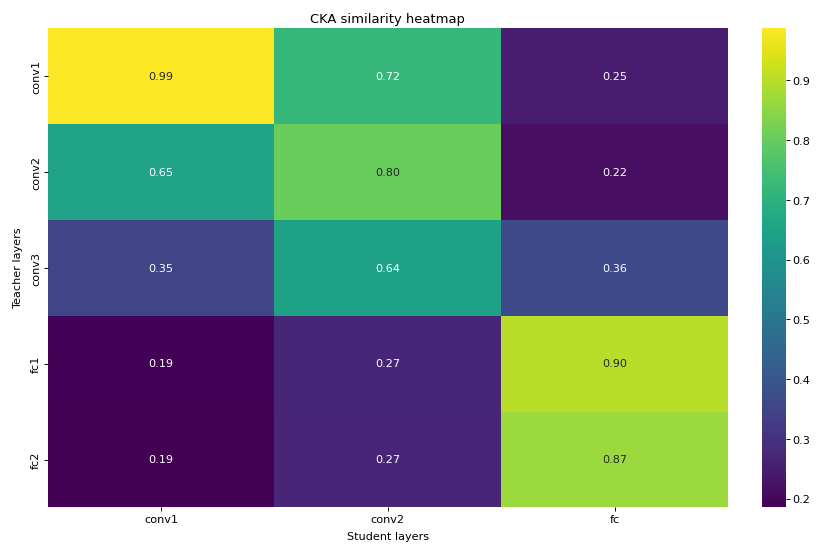

In [81]:
teacher_layers = {
    'conv1': 'features.0',
    'conv2': 'features.5',
    'conv3': 'features.10',
    'fc1': 'classifier.1',
    'fc2': 'classifier.4',
}

student_layers = {
    "conv1": "features.0",
    "conv2": "features.3",
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    teacher,
    student,
    teacher_layers,
    student_layers,
    train_loader,
    device
)
plt.figure(figsize=(6, 4))

sns.heatmap(
    cka,
    xticklabels=b_names,
    yticklabels=s_names,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Student layers")
plt.ylabel("Teacher layers")
plt.title("CKA similarity heatmap")

plt.show()

#### Between Baseline Student (no KD) and KD Student

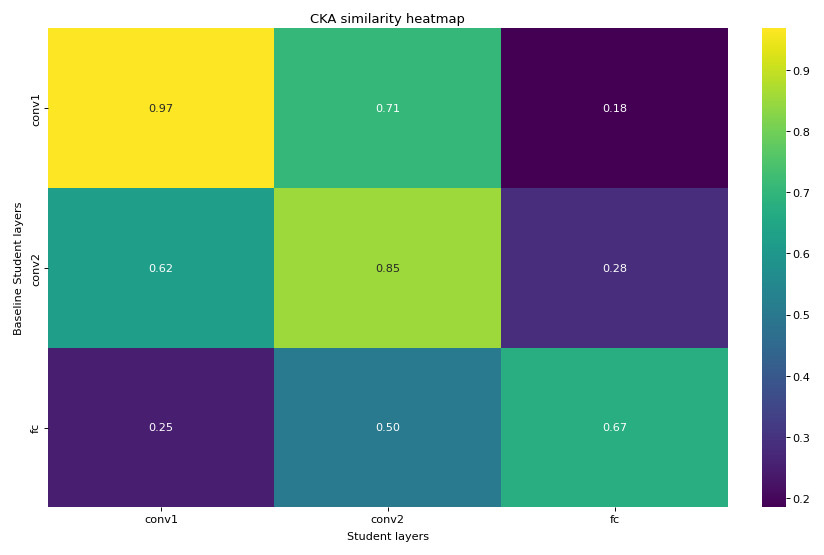

In [82]:
student_layers = {
    "conv1": "features.0",
    "conv2": "features.3",
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    baseline_student,
    student,
    student_layers,
    student_layers,
    train_loader,
    device
)
plt.figure(figsize=(6, 4))

sns.heatmap(
    cka,
    xticklabels=b_names,
    yticklabels=s_names,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Student layers")
plt.ylabel("Baseline Student layers")
plt.title("CKA similarity heatmap")

plt.show()

### Reppresentation similarity between Lottery Ticket and Baseline

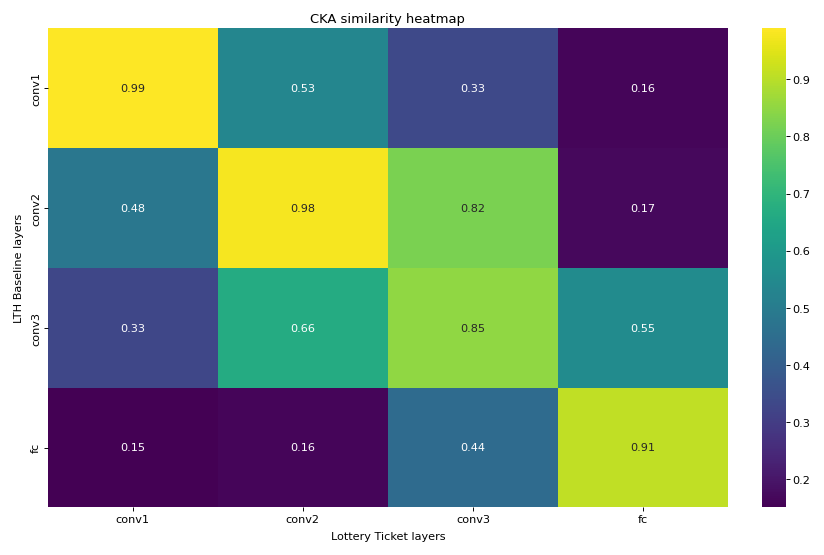

In [85]:
lth_baseline_layers = {
    "conv1": "features.0",
    "conv2": "features.5",
    "conv3": "features.10",
    "fc": "classifier.1"
}

lottery_ticket_layers = {
    "conv1": "features.0",
    "conv2": "features.5",
    "conv3": "features.10",
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    lth_baseline,
    lottery_ticket,
    lth_baseline_layers,
    lottery_ticket_layers,
    train_loader,
    device
)
plt.figure(figsize=(6, 4))

sns.heatmap(
    cka,
    xticklabels=b_names,
    yticklabels=s_names,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Lottery Ticket layers")
plt.ylabel("LTH Baseline layers")
plt.title("CKA similarity heatmap")

plt.show()

### Reppresentation similarity between KD Student and Lottery Ticket

In [43]:
student_layers = {
    "conv1": "features.0",
    "conv2": "features.3",
    "fc": "classifier.1"
}

lottery_ticket_layers = {
    "conv1": "features.0",
    "conv2": "features.5",
    "conv3": "features.10",
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    student,
    lottery_ticket,
    student_layers,
    lottery_ticket_layers,
    train_loader,
    device
)

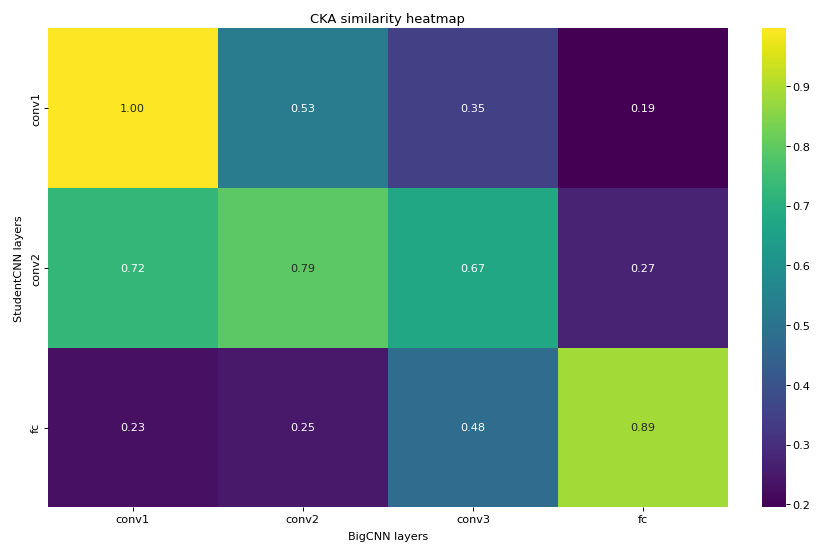

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cka,
    xticklabels=b_names,
    yticklabels=s_names,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("BigCNN layers")
plt.ylabel("StudentCNN layers")
plt.title("CKA similarity heatmap")

plt.show()


## Evaluating penultimate layer rappresentation similarity using CKA metric between Lottery tickets and Dense Network

In [ ]:
lth_baseline = BigCNN().to(device)

lth_baseline.load_state_dict(torch.load("best_lth_model_round_0.pth", map_location=device))
final_loss, final_acc = eval_epoch(lth_baseline, test_loader, nn.CrossEntropyLoss())
#print(f"LTH Baseline - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
#active_params = count_active_parameters(lth_baseline)
#print(f"Active parameters after pruning: {active_params}")


lottery_ticket = BigCNN().to(device)

parameters_to_prune = get_prunable_layers(lottery_ticket)

for module, param_name in parameters_to_prune:
    prune.identity(module, param_name)

lottery_ticket.load_state_dict(torch.load("best_lth_model_round_10.pth", map_location=device))
final_loss, final_acc = eval_epoch(lottery_ticket, test_loader, nn.CrossEntropyLoss())
#print(f"LTH Pruned lottery_ticket - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
# Calculate Sparsity
sparsity_pct = count_sparsity(lottery_ticket)
print(f"Round 10 sparsity: {sparsity_pct:.2f}%")
#active_params = count_active_parameters(lottery_ticket)
#print(f"Active parameters after pruning: {active_params}")

lth_baseline_layers = {
    "fc": "classifier.1"
}

lottery_ticket_layers = {
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    lth_baseline,
    lottery_ticket,
    lth_baseline_layers,
    lottery_ticket_layers,
    train_loader,
    device
)

print(cka[0][0])



round 10 sparsity: 89.26%
0.910390317440033



===== ROUND 1 =====
Baseline  | Acc: 0.9910 | Loss: 0.0363
Ticket    | Acc: 0.9910 | Loss: 0.0380
Sparsity  | 20.00%
CKA(fc, fc): 0.9771

===== ROUND 2 =====
Baseline  | Acc: 0.9910 | Loss: 0.0363
Ticket    | Acc: 0.9900 | Loss: 0.0423
Sparsity  | 36.00%
CKA(fc, fc): 0.9787

===== ROUND 3 =====
Baseline  | Acc: 0.9910 | Loss: 0.0363
Ticket    | Acc: 0.9920 | Loss: 0.0323
Sparsity  | 48.80%
CKA(fc, fc): 0.9706

===== ROUND 4 =====
Baseline  | Acc: 0.9910 | Loss: 0.0363
Ticket    | Acc: 0.9910 | Loss: 0.0412
Sparsity  | 59.04%
CKA(fc, fc): 0.9730

===== ROUND 5 =====
Baseline  | Acc: 0.9910 | Loss: 0.0363
Ticket    | Acc: 0.9910 | Loss: 0.0467
Sparsity  | 67.23%
CKA(fc, fc): 0.9641

===== ROUND 6 =====
Baseline  | Acc: 0.9910 | Loss: 0.0363
Ticket    | Acc: 0.9910 | Loss: 0.0418
Sparsity  | 73.79%
CKA(fc, fc): 0.9645

===== ROUND 7 =====
Baseline  | Acc: 0.9910 | Loss: 0.0363
Ticket    | Acc: 0.9890 | Loss: 0.0426
Sparsity  | 79.03%
CKA(fc, fc): 0.9559

===== ROUND 8 =====
Baseline  | A

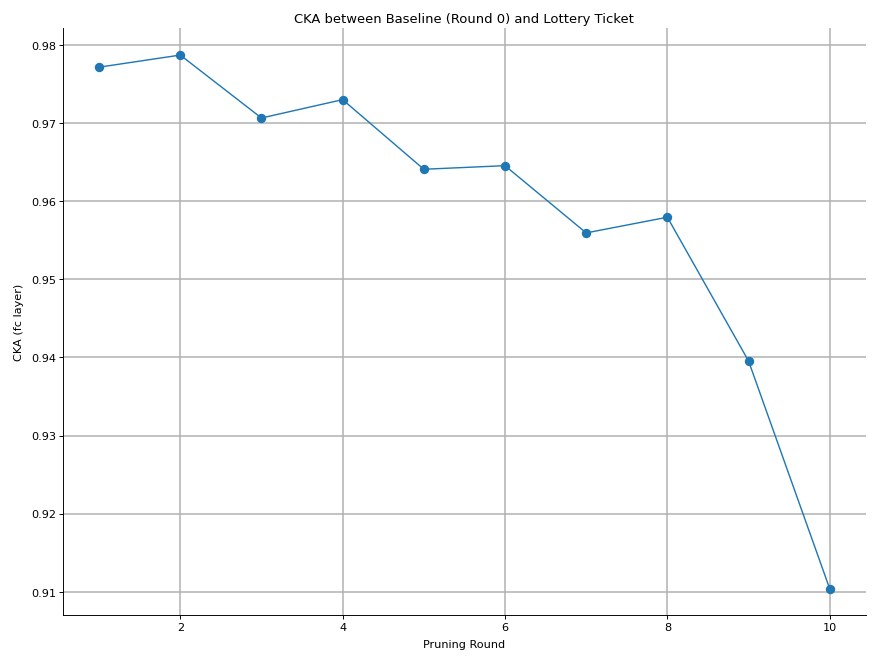

In [36]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune

criterion = nn.CrossEntropyLoss()

lth_baseline_layers = {
    "fc": "classifier.1"
}

lottery_ticket_layers = {
    "fc": "classifier.1"
}

# -------------------------
# Load baseline once (round 0)
# -------------------------
lth_baseline = BigCNN().to(device)
lth_baseline.load_state_dict(
    torch.load("best_lth_model_round_0.pth", map_location=device)
)

baseline_loss, baseline_acc = eval_epoch(
    lth_baseline, test_loader, criterion
)

# -------------------------
# Storage
# -------------------------
rounds = []
cka_values = []
sparsities = []
ticket_accuracies = []


# -------------------------
# Loop over rounds
# -------------------------
for round_id in range(1, 11):

    print(f"\n===== ROUND {round_id} =====")

    lottery_ticket = BigCNN().to(device)

    parameters_to_prune = get_prunable_layers(lottery_ticket)
    for module, param_name in parameters_to_prune:
        prune.identity(module, param_name)

    lottery_ticket.load_state_dict(
        torch.load(f"best_lth_model_round_{round_id}.pth", map_location=device)
    )

    ticket_loss, ticket_acc = eval_epoch(
        lottery_ticket, test_loader, criterion
    )

    

    sparsity_pct = count_sparsity(lottery_ticket)

    print(f"Baseline  | Acc: {baseline_acc:.4f} | Loss: {baseline_loss:.4f}")
    print(f"Ticket    | Acc: {ticket_acc:.4f} | Loss: {ticket_loss:.4f}")
    print(f"Sparsity  | {sparsity_pct:.2f}%")

    # -------------------------
    # CKA
    # -------------------------
    cka, s_names, b_names = compute_cka_matrix(
        lth_baseline,
        lottery_ticket,
        lth_baseline_layers,
        lottery_ticket_layers,
        train_loader,
        device
    )

    cka_fc = cka[0][0]
    print(f"CKA(fc, fc): {cka_fc:.4f}")

    rounds.append(round_id)
    cka_values.append(cka_fc)
    sparsities.append(sparsity_pct)
    ticket_accuracies.append(ticket_acc)

# -------------------------
# Plot CKA vs Round
# -------------------------
plt.figure()
plt.plot(rounds, cka_values, marker='o')
plt.xlabel("Pruning Round")
plt.ylabel("CKA (fc layer)")
plt.title("CKA between Baseline (Round 0) and Lottery Ticket")
plt.grid(True)
plt.show()


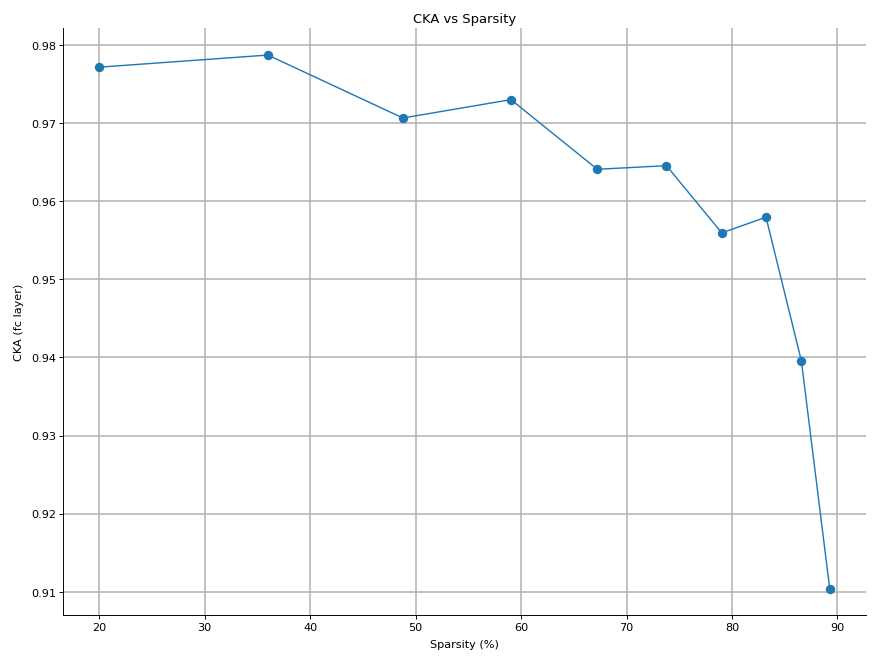

In [34]:
plt.figure()
plt.plot(sparsities, cka_values, marker='o')
plt.xlabel("Sparsity (%)")
plt.ylabel("CKA (fc layer)")
plt.title("CKA vs Sparsity")
plt.grid(True)
plt.show()


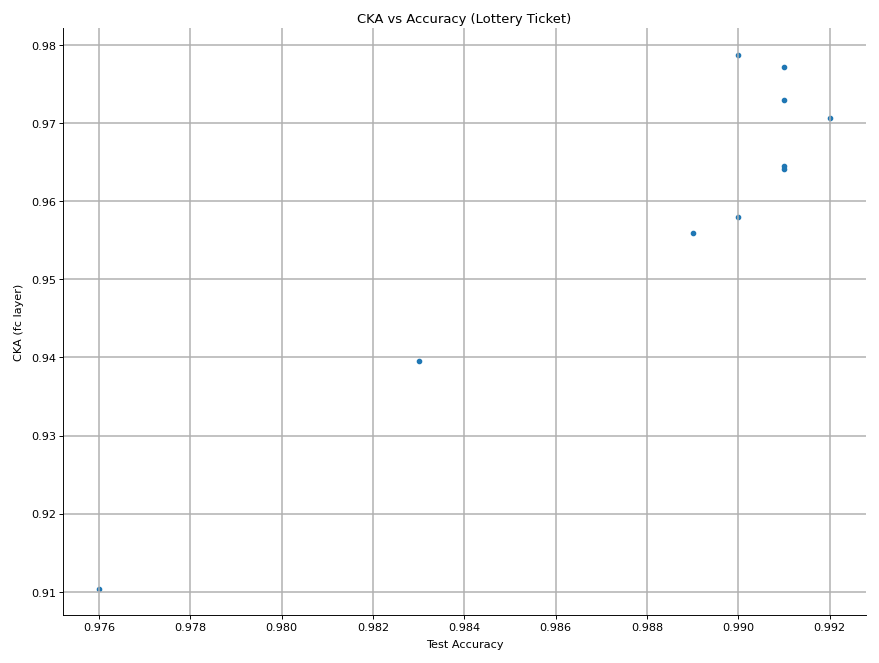

In [37]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(ticket_accuracies, cka_values)
plt.xlabel("Test Accuracy")
plt.ylabel("CKA (fc layer)")
plt.title("CKA vs Accuracy (Lottery Ticket)")
plt.grid(True)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import matplotlib.pyplot as plt
import numpy as np

criterion = nn.CrossEntropyLoss()

layers = {
    "fc": "classifier.1"
}

# -------------------------
# Load baseline (round 0)
# -------------------------
models = {}

baseline = BigCNN().to(device)
baseline.load_state_dict(
    torch.load("best_lth_model_round_0.pth", map_location=device)
)
baseline.eval()
models[0] = baseline

# -------------------------
# Load lottery tickets (rounds 1–10)
# -------------------------
round_ids = list(range(1, 11))

for round_id in round_ids:
    model = BigCNN().to(device)

    parameters_to_prune = get_prunable_layers(model)
    for module, param_name in parameters_to_prune:
        prune.identity(module, param_name)

    model.load_state_dict(
        torch.load(f"best_lth_model_round_{round_id}.pth", map_location=device)
    )

    model.eval()
    models[round_id] = model

# -------------------------
# Compute CKA matrix
# -------------------------
all_rounds = [0] + round_ids
num_models = len(all_rounds)

cka_matrix = np.zeros((num_models, num_models))

for i, r1 in enumerate(all_rounds):
    for j, r2 in enumerate(all_rounds):

        cka, _, _ = compute_cka_matrix(
            models[r1],
            models[r2],
            layers,
            layers,
            train_loader,
            device
        )

        cka_matrix[i, j] = cka[0][0]


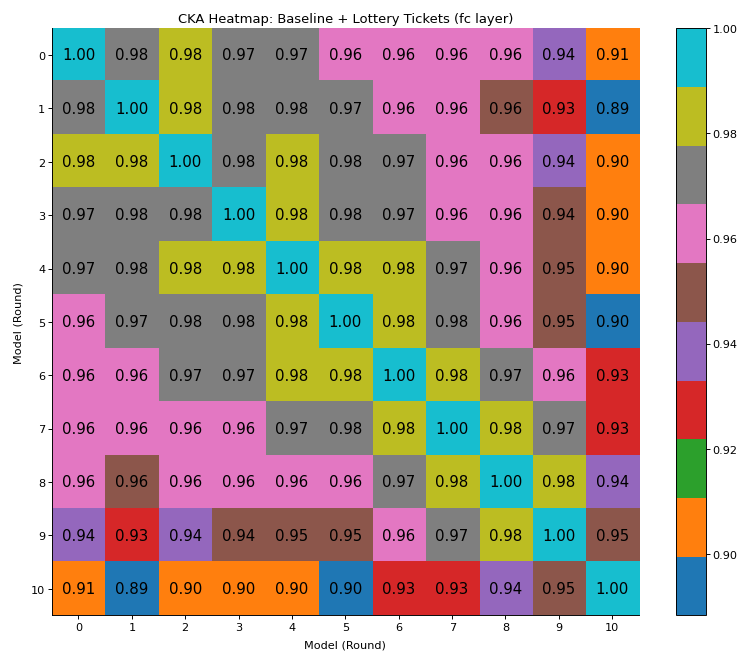

In [39]:
plt.figure()
im = plt.imshow(cka_matrix)
plt.colorbar()

plt.xticks(range(num_models), all_rounds)
plt.yticks(range(num_models), all_rounds)

plt.xlabel("Model (Round)")
plt.ylabel("Model (Round)")
plt.title("CKA Heatmap: Baseline + Lottery Tickets (fc layer)")

# -------------------------
# Annotate each cell
# -------------------------
for i in range(num_models):
    for j in range(num_models):
        plt.text(
            j, i,
            f"{cka_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if cka_matrix[i, j] < 0.5 else "black",
            fontsize=8
        )

plt.show()


## Lottery ticket hypotesis, linear mode connectivity and CKA
In this section I look for a link between linear mode connectivity in IMP(Iterative Magnitude Pruning) as per paper Frankle et al., “Linear Mode Connectivity and the Lottery Ticket Hypothesis” (ICML 2020), and it's link with CKA.
Ideally linearly connected models should have high CKA similarity, first I will generate one exemple of just a couple of same sparsity lottery thicket coming form different and from same inizialization (SGD descent still keeps noise by reciving random batches) verifing linear mode connectivity and CKA. Then to strenghten the findings I simply calculate the average of CKA from one ticket to all others (should I do this for all tikets?? idk)

In [22]:
def run_lth_from_starting_model(model,initial_state, train_loader, test_loader, rounds=5, prune_amount=0.2, epochs_per_round=5,device="cpu"):
    """Recives a trained model to start LTH from, first it prunes it, then rewinds to initial weights."""

    parameters_to_prune = get_prunable_layers(model)
    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=prune_amount,
    )

    # Reset Weights (The Rewind)
    with torch.no_grad():
        for name, param in model.named_parameters():
            clean_name = name.replace("_orig", "")
            if clean_name in initial_state:
                 param.data.copy_(initial_state[clean_name].data)
    
    
    print(f"Initial parameters: {sum(p.numel() for p in model.parameters())}")

    for round_idx in range(rounds):
        print(f"\n--- Round {round_idx + 1} ---")

        
        # Train (Re-init optimizer to reset momentum)
        optimizer = optim.Adam(model.parameters(), lr=0.001) 
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs_per_round)
        
        history = train_model(
        model, 
        device, 
        train_loader, 
        test_loader, 
        optimizer,
        scheduler,
        epochs=epochs_per_round,
        round_idx=round_idx  # <--- Add this line
        )

        best_acc = max(history['val_acc'])

        # Calculate Sparsity
        sparsity_pct = count_sparsity(model)
        print(f"Sparsity after pruning: {sparsity_pct:.2f}%")
        active_params = count_active_parameters(model)
        print(f"Active parameters after pruning: {active_params}")

        # Prune
        parameters_to_prune = get_prunable_layers(model)
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=prune_amount,
        )

        wandb.log({
            "active_parameters": active_params,
            "sparsity_percentage": sparsity_pct,
            "round": round_idx,
            "best_val_acc": best_acc,
            })
        
        # Reset Weights (The Rewind)
        with torch.no_grad():
            for name, param in model.named_parameters():
                clean_name = name.replace("_orig", "")
                if clean_name in initial_state:
                     param.data.copy_(initial_state[clean_name].data)

        print("Weights reset to initialization.")

    remove_pruning_reparam(model)

    #print(f"LTH Pruned model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
    return model

In [44]:
dense_model = BigCNN().to(device)
initial_state = copy.deepcopy(dense_model.state_dict())
prune_amount = 0.2

optimizer = torch.optim.Adam(dense_model.parameters(), lr=1e-2)
epochs = 200
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
criterion = nn.CrossEntropyLoss()

best_test_acc = 0.0
model_path = "best_dense_model.pth"

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(dense_model, train_loader, optimizer, criterion)
    test_loss, test_acc = eval_epoch(dense_model, test_loader, criterion)

    # Step the scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(dense_model.state_dict(), model_path)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Test Acc: {test_acc:.3f} | Train Acc: {train_acc:.3f} | LR: {current_lr:.6f}")



Epoch 010 | Test Acc: 0.966 | Train Acc: 0.919 | LR: 0.009938
Epoch 020 | Test Acc: 0.973 | Train Acc: 0.952 | LR: 0.009755
Epoch 030 | Test Acc: 0.977 | Train Acc: 0.960 | LR: 0.009455
Epoch 040 | Test Acc: 0.985 | Train Acc: 0.974 | LR: 0.009045
Epoch 050 | Test Acc: 0.990 | Train Acc: 0.980 | LR: 0.008536
Epoch 060 | Test Acc: 0.993 | Train Acc: 0.986 | LR: 0.007939
Epoch 070 | Test Acc: 0.993 | Train Acc: 0.987 | LR: 0.007270
Epoch 080 | Test Acc: 0.990 | Train Acc: 0.988 | LR: 0.006545
Epoch 090 | Test Acc: 0.993 | Train Acc: 0.984 | LR: 0.005782
Epoch 100 | Test Acc: 0.995 | Train Acc: 0.994 | LR: 0.005000
Epoch 110 | Test Acc: 0.993 | Train Acc: 0.992 | LR: 0.004218
Epoch 120 | Test Acc: 0.994 | Train Acc: 0.990 | LR: 0.003455
Epoch 130 | Test Acc: 0.995 | Train Acc: 0.992 | LR: 0.002730
Epoch 140 | Test Acc: 0.994 | Train Acc: 0.993 | LR: 0.002061
Epoch 150 | Test Acc: 0.993 | Train Acc: 0.997 | LR: 0.001464
Epoch 160 | Test Acc: 0.994 | Train Acc: 0.997 | LR: 0.000955
Epoch 17

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rounds = 9
num_tickets = 10
base_seed = 42

for run_idx in range(num_tickets):

    seed = base_seed + run_idx * 100  # spaced seeds
    g = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(
        train_ds,
        batch_size=128,
        shuffle=True,
        generator=g
    )

    # 🔹 Fresh model EVERY time
    model = BigCNN().to(device)
    model.load_state_dict(torch.load("best_dense_model.pth", map_location=device))
    

    wandb.init(
        project="mnist-1d-KDvsLTH",
        name=f"LTH-CNN-Run{run_idx}",
        group="Linear-mode-connectivity",
        config={
            "learning_rate": 0.001,
            "rounds": rounds,
            "prune_amount": 0.2,
            "epochs_per_round": 200,
            "architecture": "BigCNN",
            "seed": seed
        }
    )

    _ = run_lth_from_starting_model(
        model,
        initial_state,          # IMPORTANT: need to run the dense model cell first
        train_loader,
        test_loader,
        rounds=rounds,
        prune_amount=0.2,
        epochs_per_round=200,
        device=device
    )

    # Save final ticket (aliasing is fine)
    torch.save(
        torch.load(f"best_lth_model_round_{rounds-1}.pth"),
        f"lth_linearCon_run{run_idx}.pth"
    )

    wandb.finish()


Initial parameters: 60938

--- Round 1 ---
Round 0 | Epoch 1 | Val Acc: 42.60%
Round 0 | Epoch 2 | Val Acc: 58.40%
Round 0 | Epoch 3 | Val Acc: 68.00%
Round 0 | Epoch 4 | Val Acc: 74.10%
Round 0 | Epoch 5 | Val Acc: 75.50%
Round 0 | Epoch 6 | Val Acc: 75.80%
Round 0 | Epoch 7 | Val Acc: 75.90%
Round 0 | Epoch 8 | Val Acc: 76.60%
Round 0 | Epoch 9 | Val Acc: 78.90%
Round 0 | Epoch 10 | Val Acc: 81.90%
Round 0 | Epoch 11 | Val Acc: 83.90%
Round 0 | Epoch 12 | Val Acc: 81.70%
Round 0 | Epoch 13 | Val Acc: 87.10%
Round 0 | Epoch 14 | Val Acc: 91.30%
Round 0 | Epoch 15 | Val Acc: 91.20%
Round 0 | Epoch 16 | Val Acc: 92.50%
Round 0 | Epoch 17 | Val Acc: 93.40%
Round 0 | Epoch 18 | Val Acc: 93.40%
Round 0 | Epoch 19 | Val Acc: 93.60%
Round 0 | Epoch 20 | Val Acc: 93.70%
Round 0 | Epoch 21 | Val Acc: 94.40%
Round 0 | Epoch 22 | Val Acc: 94.10%
Round 0 | Epoch 23 | Val Acc: 93.40%
Round 0 | Epoch 24 | Val Acc: 94.50%
Round 0 | Epoch 25 | Val Acc: 94.70%
Round 0 | Epoch 26 | Val Acc: 93.80%
Roun

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Round 8 | Epoch 200 | Val Acc: 98.20%
Sparsity after pruning: 86.58%
Layer: features.0           | Active:      112 /      160 (70.00%)
Layer: features.5           | Active:     1091 /    10240 (10.65%)
Layer: features.10          | Active:     2872 /    40960 (7.01%)
Layer: classifier.1         | Active:     3628 /     8192 (44.29%)
Layer: classifier.4         | Active:      375 /      640 (58.59%)
------------------------------------------------------------
TOTAL ACTIVE PARAMETERS: 8,078 / 60,192
GLOBAL DENSITY: 13.42%
Active parameters after pruning: 8078
Weights reset to initialization.


active_parameters,█▆▅▄▃▂▂▁▁
best_val_acc,▄▇▂▄▅█▂▁▂
round,▁▂▃▄▅▅▆▇█
round_0/train_loss,█▇▇▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_0/val_acc,▁▄▅▅▇▇▇▇▇█▇█████████████████████████████
round_1/train_loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_1/val_acc,▁▅▆▆▇▇▇██▇███▇██████████████████████████
round_2/train_loss,█▇▆▆▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_2/val_acc,▁▅▅▆▇▇██████████████████████████████████
round_3/train_loss,█▆▆▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+12,...


Initial parameters: 60938

--- Round 1 ---
Round 0 | Epoch 1 | Val Acc: 41.40%
Round 0 | Epoch 2 | Val Acc: 59.30%
Round 0 | Epoch 3 | Val Acc: 68.20%
Round 0 | Epoch 4 | Val Acc: 74.60%
Round 0 | Epoch 5 | Val Acc: 76.10%
Round 0 | Epoch 6 | Val Acc: 75.60%
Round 0 | Epoch 7 | Val Acc: 75.90%
Round 0 | Epoch 8 | Val Acc: 77.20%
Round 0 | Epoch 9 | Val Acc: 78.70%
Round 0 | Epoch 10 | Val Acc: 80.70%
Round 0 | Epoch 11 | Val Acc: 84.30%
Round 0 | Epoch 12 | Val Acc: 87.10%
Round 0 | Epoch 13 | Val Acc: 88.20%
Round 0 | Epoch 14 | Val Acc: 90.10%
Round 0 | Epoch 15 | Val Acc: 91.10%
Round 0 | Epoch 16 | Val Acc: 91.90%
Round 0 | Epoch 17 | Val Acc: 92.60%
Round 0 | Epoch 18 | Val Acc: 93.10%
Round 0 | Epoch 19 | Val Acc: 92.80%
Round 0 | Epoch 20 | Val Acc: 92.80%
Round 0 | Epoch 21 | Val Acc: 92.60%
Round 0 | Epoch 22 | Val Acc: 94.10%
Round 0 | Epoch 23 | Val Acc: 93.30%
Round 0 | Epoch 24 | Val Acc: 93.80%
Round 0 | Epoch 25 | Val Acc: 94.70%
Round 0 | Epoch 26 | Val Acc: 94.80%
Roun

...

active_parameters,█▆▅▄▃▂▂▁▁
best_val_acc,▇▆▇█▅▄▄▂▁
round,▁▂▃▄▅▅▆▇█
round_0/train_loss,█▄▄▃▃▃▃▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_0/val_acc,▁▃▅▇▇▇██████████████████████████████████
round_1/train_loss,█▆▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_1/val_acc,▁▄▆▆▇▇▇▇████████████████████████████████
round_2/train_loss,█▇▅▄▃▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_2/val_acc,▁▂▃▄▆▇▇▇█▇▇██▇██████████████████████████
round_3/train_loss,█▆▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+12,...


Initial parameters: 60938

--- Round 1 ---
Round 0 | Epoch 1 | Val Acc: 40.50%
Round 0 | Epoch 2 | Val Acc: 58.70%
Round 0 | Epoch 3 | Val Acc: 67.40%
Round 0 | Epoch 4 | Val Acc: 72.40%
Round 0 | Epoch 5 | Val Acc: 74.70%
Round 0 | Epoch 6 | Val Acc: 76.00%
Round 0 | Epoch 7 | Val Acc: 75.60%
Round 0 | Epoch 8 | Val Acc: 76.60%
Round 0 | Epoch 9 | Val Acc: 77.70%
Round 0 | Epoch 10 | Val Acc: 77.40%
Round 0 | Epoch 11 | Val Acc: 79.40%
Round 0 | Epoch 12 | Val Acc: 82.20%
Round 0 | Epoch 13 | Val Acc: 86.70%
Round 0 | Epoch 14 | Val Acc: 90.60%
Round 0 | Epoch 15 | Val Acc: 89.50%
Round 0 | Epoch 16 | Val Acc: 91.90%
Round 0 | Epoch 17 | Val Acc: 92.40%
Round 0 | Epoch 18 | Val Acc: 93.10%
Round 0 | Epoch 19 | Val Acc: 92.90%
Round 0 | Epoch 20 | Val Acc: 92.90%
Round 0 | Epoch 21 | Val Acc: 92.50%
Round 0 | Epoch 22 | Val Acc: 93.80%
Round 0 | Epoch 23 | Val Acc: 94.30%
Round 0 | Epoch 24 | Val Acc: 94.90%
Round 0 | Epoch 25 | Val Acc: 93.30%
Round 0 | Epoch 26 | Val Acc: 94.20%
Roun

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Round 8 | Epoch 200 | Val Acc: 98.10%
Sparsity after pruning: 86.58%
Layer: features.0           | Active:      115 /      160 (71.88%)
Layer: features.5           | Active:     1044 /    10240 (10.20%)
Layer: features.10          | Active:     2879 /    40960 (7.03%)
Layer: classifier.1         | Active:     3668 /     8192 (44.78%)
Layer: classifier.4         | Active:      372 /      640 (58.12%)
------------------------------------------------------------
TOTAL ACTIVE PARAMETERS: 8,078 / 60,192
GLOBAL DENSITY: 13.42%
Active parameters after pruning: 8078
Weights reset to initialization.


active_parameters,█▆▅▄▃▂▂▁▁
best_val_acc,▇█▇█▆▇▅▄▁
round,▁▂▃▄▅▅▆▇█
round_0/train_loss,█▅▄▄▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_0/val_acc,▁▃▅▇▇▇▇█████████████████████████████████
round_1/train_loss,██▆▄▄▃▃▂▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_1/val_acc,▁▄▅▆▇▇▇█▇███████████████████████████████
round_2/train_loss,██▇▆▅▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_2/val_acc,▁▄▆▇▇▇▇█████████████████████████████████
round_3/train_loss,█▅▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+12,...


LTH Pruned model run1 - Acc: 0.9920 | Loss: 0.0426
LTH Pruned model run2 - Acc: 0.9890 | Loss: 0.0350


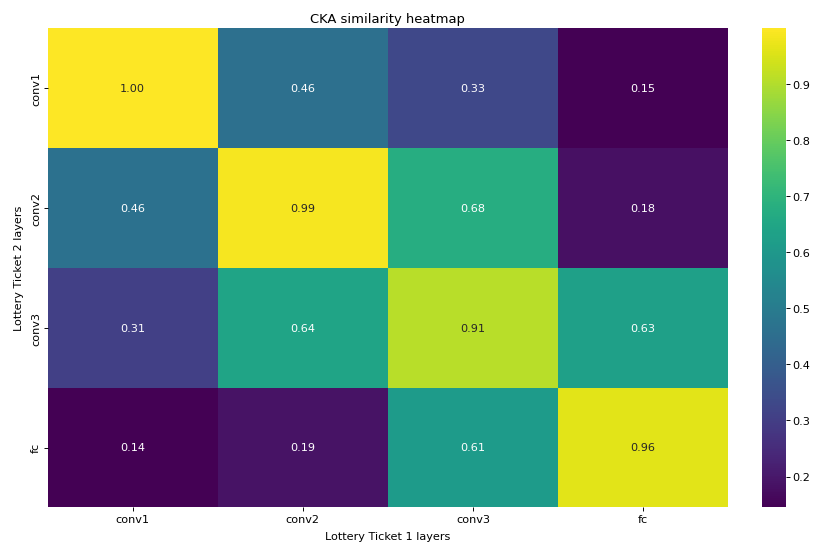

In [66]:
pruned_model1 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(pruned_model1)
for m, p in parameters_to_prune:
    prune.identity(m, p)

pruned_model1.load_state_dict(torch.load("lth_linearCon_run1.pth", map_location=device))
final_loss, final_acc = eval_epoch(pruned_model1, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned model run1 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

pruned_model1.eval()
    
pruned_model2 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(pruned_model2)
for m, p in parameters_to_prune:
    prune.identity(m, p)

pruned_model2.load_state_dict(torch.load("lth_linearCon_run4.pth", map_location=device))
final_loss, final_acc = eval_epoch(pruned_model2, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned model run2 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

pruned_model2.eval()

lottery_ticket_layers = {
    "conv1": "features.0",
    "conv2": "features.5",
    "conv3": "features.10",
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    pruned_model1,
    pruned_model2,
    lottery_ticket_layers,
    lottery_ticket_layers,
    test_loader,
    device
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cka,
    xticklabels=b_names,
    yticklabels=s_names,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Lottery Ticket 1 layers")
plt.ylabel("Lottery Ticket 2 layers")
plt.title("CKA similarity heatmap")

plt.show()

In [65]:
## guarda il CKA di tutti e due i modelli pruned_model1 e pruned_model2 verso il modello denso ( salva il modello denso prima di iniziare LTH)

dense_model = BigCNN().to(device)
dense_model.load_state_dict(torch.load("best_dense_model.pth", map_location=device))
dense_model.eval()
for i in range(9):
    pruned_model = BigCNN().to(device)
    # Apply pruning structure FIRST
    parameters_to_prune = get_prunable_layers(pruned_model)
    for m, p in parameters_to_prune:
        prune.identity(m, p)

    pruned_model.load_state_dict(torch.load(f"lth_linearCon_run{i}.pth", map_location=device))
    final_loss, final_acc = eval_epoch(pruned_model, test_loader, nn.CrossEntropyLoss())
    #print(f"LTH Pruned model run{i} - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

    layers = { 
        "fc": "classifier.1"
    }
    cka, s_names, b_names = compute_cka_matrix(
        dense_model,
        pruned_model,
        layers,
        layers,
        test_loader,
        device
    )
    print(f"CKA dense vs lottery ticket: {cka[0][0]:.4f}")
    


CKA dense vs lottery ticket: 0.9228
CKA dense vs lottery ticket: 0.9060
CKA dense vs lottery ticket: 0.9131
CKA dense vs lottery ticket: 0.8896
CKA dense vs lottery ticket: 0.9036
CKA dense vs lottery ticket: 0.9124
CKA dense vs lottery ticket: 0.9024
CKA dense vs lottery ticket: 0.9183
CKA dense vs lottery ticket: 0.8988


In [ ]:
pruned_model1 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(pruned_model1)
for m, p in parameters_to_prune:
    prune.identity(m, p)

pruned_model1.load_state_dict(torch.load("lth_linearCon_run0.pth", map_location=device))
final_loss, final_acc = eval_epoch(pruned_model1, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned model run1 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

pruned_model1.eval()
    
pruned_model2 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(pruned_model2)
for m, p in parameters_to_prune:
    prune.identity(m, p)

pruned_model2.load_state_dict(torch.load("lth_linearCon_run9.pth", map_location=device))
final_loss, final_acc = eval_epoch(pruned_model2, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned model run2 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

pruned_model2.eval()

lottery_ticket_layers = {
    "fc": "classifier.1"
}

cka, s_names, b_names = compute_cka_matrix(
    pruned_model1,
    pruned_model2,
    lottery_ticket_layers,
    lottery_ticket_layers,
    test_loader,
    device
)

print(f"CKA representation: {cka[0][0]:.4f}")

LTH Pruned model run1 - Acc: 0.9920 | Loss: 0.0442
LTH Pruned model run2 - Acc: 0.9920 | Loss: 0.0426
CKA representation: 0.9678


## All pair CKA

In [34]:
def load_pruned_ticket(ckpt_path, device):
    model = BigCNN().to(device)

    # Apply pruning structure FIRST
    parameters_to_prune = get_prunable_layers(model)
    for m, p in parameters_to_prune:
        prune.identity(m, p)

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    return model

num_tickets = 10
ticket_paths = [f"lth_linearCon_run{i}.pth" for i in range(num_tickets)]

tickets = [
    load_pruned_ticket(path, device)
    for path in ticket_paths
]

In [35]:
import numpy as np

lottery_ticket_layers = {
    "fc": "classifier.1"  # penultimate layer
}

cka_values = []
cka_matrix = np.zeros((num_tickets, num_tickets))

for i in range(num_tickets):
    for j in range(i + 1, num_tickets):
        cka, _, _ = compute_cka_matrix(
            tickets[i],
            tickets[j],
            lottery_ticket_layers,
            lottery_ticket_layers,
            test_loader,
            device
        )

        cka_val = cka[0][0]
        cka_values.append(cka_val)
        cka_matrix[i, j] = cka_val
        cka_matrix[j, i] = cka_val

        print(f"CKA(ticket {i}, ticket {j}) = {cka_val:.4f}")

cka_values = np.array(cka_values)

print(
    f"\nPairwise CKA (penultimate layer): "
    f"mean = {cka_values.mean():.4f}, "
    f"std = {cka_values.std():.4f}"
)


CKA(ticket 0, ticket 1) = 0.9678
CKA(ticket 0, ticket 2) = 0.9649
CKA(ticket 0, ticket 3) = 0.9543
CKA(ticket 0, ticket 4) = 0.9605
CKA(ticket 0, ticket 5) = 0.9652
CKA(ticket 0, ticket 6) = 0.9610
CKA(ticket 0, ticket 7) = 0.9622
CKA(ticket 0, ticket 8) = 0.9618
CKA(ticket 0, ticket 9) = 0.9631
CKA(ticket 1, ticket 2) = 0.9635
CKA(ticket 1, ticket 3) = 0.9547
CKA(ticket 1, ticket 4) = 0.9602
CKA(ticket 1, ticket 5) = 0.9644
CKA(ticket 1, ticket 6) = 0.9625
CKA(ticket 1, ticket 7) = 0.9560
CKA(ticket 1, ticket 8) = 0.9625
CKA(ticket 1, ticket 9) = 0.9621
CKA(ticket 2, ticket 3) = 0.9633
CKA(ticket 2, ticket 4) = 0.9581
CKA(ticket 2, ticket 5) = 0.9654
CKA(ticket 2, ticket 6) = 0.9604
CKA(ticket 2, ticket 7) = 0.9644
CKA(ticket 2, ticket 8) = 0.9533
CKA(ticket 2, ticket 9) = 0.9650
CKA(ticket 3, ticket 4) = 0.9564
CKA(ticket 3, ticket 5) = 0.9600
CKA(ticket 3, ticket 6) = 0.9594
CKA(ticket 3, ticket 7) = 0.9575
CKA(ticket 3, ticket 8) = 0.9502
CKA(ticket 3, ticket 9) = 0.9660
CKA(ticket

## Linear interpolation and CKA

In [26]:
def interpolate_models(model_a, model_b, alpha):
    interp_model = BigCNN().to(next(model_a.parameters()).device)

    # Apply pruning structure FIRST
    parameters_to_prune = get_prunable_layers(interp_model)
    for m, p in parameters_to_prune:
        prune.identity(m, p)

    state_dict = {}
    for (k, v_a), (_, v_b) in zip(
        model_a.state_dict().items(),
        model_b.state_dict().items()
    ):
        state_dict[k] = (1 - alpha) * v_a + alpha * v_b

    interp_model.load_state_dict(state_dict)
    interp_model.eval()
    return interp_model

def recompute_bn_stats(model, data_loader, device, num_batches=50):
    model.train()
    with torch.no_grad():
        for i, (x, _) in enumerate(data_loader):
            if i >= num_batches:
                break
            x = x.to(device)
            model(x)
    model.eval()

In [42]:
alphas = np.linspace(0.0, 1.0, 11)

cka_alphas = []

for alpha in alphas:
    interp_model = interpolate_models(pruned_model1, pruned_model2, alpha)
    recompute_bn_stats(interp_model, train_loader, device)
    
    cka, _, _ = compute_cka_matrix(
        pruned_model1,
        interp_model,
        lottery_ticket_layers,
        lottery_ticket_layers,
        test_loader,
        device
    )

    cka_val = cka[0][0]
    cka_alphas.append(cka_val)

    print(f"α={alpha:.2f} | CKA = {cka_val:.4f}")


α=0.00 | CKA = 0.9998
α=0.10 | CKA = 0.9973
α=0.20 | CKA = 0.9889
α=0.30 | CKA = 0.9721
α=0.40 | CKA = 0.9505
α=0.50 | CKA = 0.9363
α=0.60 | CKA = 0.9411
α=0.70 | CKA = 0.9567
α=0.80 | CKA = 0.9654
α=0.90 | CKA = 0.9680
α=1.00 | CKA = 0.9680


In [43]:
losses = []
errors = []

criterion = nn.CrossEntropyLoss()

for alpha in alphas:
    interp_model = interpolate_models(pruned_model1, pruned_model2, alpha)

    loss, acc = eval_epoch(
        interp_model,
        test_loader,
        criterion
    )

    error = 1.0 - acc

    losses.append(loss)
    errors.append(error)

    print(f"α={alpha:.2f} | Loss={loss:.4f} | Error={error:.4f}")


α=0.00 | Loss=0.0442 | Error=0.0080
α=0.10 | Loss=0.1388 | Error=0.0490
α=0.20 | Loss=0.3556 | Error=0.1060
α=0.30 | Loss=0.7416 | Error=0.2360
α=0.40 | Loss=1.1918 | Error=0.3690
α=0.50 | Loss=1.3844 | Error=0.4190
α=0.60 | Loss=1.1647 | Error=0.3770
α=0.70 | Loss=0.6950 | Error=0.2290
α=0.80 | Loss=0.3098 | Error=0.0980
α=0.90 | Loss=0.1163 | Error=0.0370
α=1.00 | Loss=0.0426 | Error=0.0080


In [44]:
endpoint_error = max(errors[0], errors[-1])
max_interp_error = max(errors)

error_barrier = max_interp_error - endpoint_error

print(f"Max interpolation error: {max_interp_error:.4f}")
print(f"Error barrier: {error_barrier:.4f}")


Max interpolation error: 0.4190
Error barrier: 0.4110


In [45]:
for name, buf in pruned_model1.named_buffers():
    if "mask" in name:
        assert torch.equal(
            buf,
            dict(pruned_model2.named_buffers())[name]
        )


AssertionError: 

### Retraining the classifier of the interpolated model

In [22]:
pruned_model1 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(pruned_model1)
for m, p in parameters_to_prune:
    prune.identity(m, p)

pruned_model1.load_state_dict(torch.load("lth_linearCon_run1.pth", map_location=device))
final_loss, final_acc = eval_epoch(pruned_model1, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned model run1 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

pruned_model1.eval()
    
pruned_model2 = BigCNN().to(device)

# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(pruned_model2)
for m, p in parameters_to_prune:
    prune.identity(m, p)

pruned_model2.load_state_dict(torch.load("lth_linearCon_run4.pth", map_location=device))
final_loss, final_acc = eval_epoch(pruned_model2, test_loader, nn.CrossEntropyLoss())
print(f"LTH Pruned model run2 - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

pruned_model2.eval()

LTH Pruned model run1 - Acc: 0.9920 | Loss: 0.0426
LTH Pruned model run2 - Acc: 0.9890 | Loss: 0.0350


BigCNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()


In [38]:
alpha = 0.5
interp_model = interpolate_models(pruned_model1, pruned_model2, alpha)
interp_model.to(device)
for name, param in interp_model.named_parameters():
    param.requires_grad = False

head = interp_model.classifier[4]

trainable_params = []

if hasattr(head, "weight_orig"):
    head.weight_orig.requires_grad = True
    trainable_params.append(head.weight_orig)
else:
    head.weight.requires_grad = True
    trainable_params.append(head.weight)

if head.bias is not None:
    head.bias.requires_grad = True
    trainable_params.append(head.bias)

with torch.no_grad():
    if hasattr(head, "weight_orig"):
        nn.init.kaiming_normal_(head.weight_orig)
    else:
        nn.init.kaiming_normal_(head.weight)

    if head.bias is not None:
        nn.init.zeros_(head.bias)

for name, param in interp_model.named_parameters():
    print(name, param.requires_grad)

features.0.bias False
features.0.weight_orig False
features.1.weight False
features.1.bias False
features.5.bias False
features.5.weight_orig False
features.6.weight False
features.6.bias False
features.10.bias False
features.10.weight_orig False
features.11.weight False
features.11.bias False
classifier.1.bias False
classifier.1.weight_orig False
classifier.4.bias True
classifier.4.weight_orig True


In [40]:
head_epochs = 50
optimizer = torch.optim.Adam(
    trainable_params,
    lr=1e-3
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=head_epochs
)

wandb.init(
    project="mnist-1d-KDvsLTH",
    name=f"LTH-Interp-Head-Retrain-Alpha{alpha}",
    group="Linear-mode-connectivity",
    config={
        "learning_rate": 0.001,
        "epochs": head_epochs,
        "architecture": "BigCNN-Interp-Head-Retrain",
        "alpha": alpha
    }
)

history = train_model(
    interp_model,
    device,
    train_loader,
    test_loader,
    optimizer,
    scheduler,
    epochs=head_epochs,
    round_idx="head_retrain_alpha_0.5"
)
wandb.finish()

wandb: Currently logged in as: matteo-piras (matteo-piras-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Round head_retrain_alpha_0.5 | Epoch 1 | Val Acc: 42.40%
Round head_retrain_alpha_0.5 | Epoch 2 | Val Acc: 43.90%
Round head_retrain_alpha_0.5 | Epoch 3 | Val Acc: 65.40%
Round head_retrain_alpha_0.5 | Epoch 4 | Val Acc: 78.90%
Round head_retrain_alpha_0.5 | Epoch 5 | Val Acc: 80.40%
Round head_retrain_alpha_0.5 | Epoch 6 | Val Acc: 85.10%
Round head_retrain_alpha_0.5 | Epoch 7 | Val Acc: 92.30%
Round head_retrain_alpha_0.5 | Epoch 8 | Val Acc: 92.30%
Round head_retrain_alpha_0.5 | Epoch 9 | Val Acc: 93.50%
Round head_retrain_alpha_0.5 | Epoch 10 | Val Acc: 95.10%
Round head_retrain_alpha_0.5 | Epoch 11 | Val Acc: 95.60%
Round head_retrain_alpha_0.5 | Epoch 12 | Val Acc: 95.60%
Round head_retrain_alpha_0.5 | Epoch 13 | Val Acc: 95.60%
Round head_retrain_alpha_0.5 | Epoch 14 | Val Acc: 96.10%
Round head_retrain_alpha_0.5 | Epoch 15 | Val Acc: 95.90%
Round head_retrain_alpha_0.5 | Epoch 16 | Val Acc: 96.20%
Round head_retrain_alpha_0.5 | Epoch 17 | Val Acc: 96.20%
Round head_retrain_alph

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Round head_retrain_alpha_0.5 | Epoch 49 | Val Acc: 96.80%
Round head_retrain_alpha_0.5 | Epoch 50 | Val Acc: 96.50%


round_head_retrain_alpha_0.5/train_loss,█▇▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
round_head_retrain_alpha_0.5/val_acc,▁▁▄▆▆▇▇█████████████████████████████████
round_head_retrain_alpha_0.5/train_loss,0.2907
round_head_retrain_alpha_0.5/val_acc,96.5


Sto affrontando il seguente problema: Lottery ticket diversi hanno un alto CKA, vorrei mostrare se sono connessi in termini di LCM però non posso, dato che le mschere di pruning di due ticket diversi sono diverse questo rompe la LMC tecnincamente parlando i due modelli lavorano in spazi di rappresentazione diversi (anche se la CKA è alta???) quindi forse non è proprio possibile connetterli, gemini ha sparato tre paper sull'argomento: Going Beyond Linear Mode Connectivity: The Layerwise Linear Feature Connectivity" (2023), "Git Re-Basin: Merging Models modulo Permutation Symmetries" (2022), "The Triangle of Similarity: A Multi-Faceted Framework" (2026/Recent), "Taxonomizing local versus global structure in neural network loss landscapes" (2021).

Forse vale la pena leggere questo paper: The Triangle of Similarity: A Multi-Faceted Framework dove secondo gemini CKA e LMC sono discusse a confronto

Ma allora come fanno nel paper "Linear Mode Connectivity and the Lottery Ticket Hypothesis"? Mi sembra di aver capito che qui prima trovano una maschera con IMP dopodiche la riallenano (sempre partendo dalla stessa inizializzazione) randomizando la discesa SGD, in questo modo ottengono modelli diversi (?) con la stessa struttura; Potrei fare la stessa cosa e poi valutare la CKA per aggiungere ai risultati di quel ppaper

# Why High CKA Can Coexist with Very Poor Performance

**Observation**
- Max interpolation error ≈ **0.419**
- Error barrier ≈ **0.411** (peak at α = 0.5)
- CKA (penultimate layer) at α = 0.5 ≈ **0.936**

At first glance this seems contradictory:  
*how can a model with a representation very similar to a well-performing one perform so poorly?*

---

## 1. What CKA Actually Measures

Centered Kernel Alignment (CKA) between penultimate layers measures:

- similarity of the **geometry of representations**
- invariance to **rotation, scaling, and sign**
- alignment of **relative distances between samples**

CKA **does not measure**:
- correctness of predictions
- decision boundary alignment
- quality of the classifier head
- calibration of logits

**CKA answers:**
> *Do two models embed data in a similar geometric structure?*

**CKA does NOT answer:**
> *Do they make the same predictions?*

---

## 2. Representation vs Classifier Mismatch

CKA is computed on the **penultimate layer**, not on the final logits.

At α = 0.5:
- the **representation remains meaningful**
- the **classifier head is a linear interpolation** of two independently trained classifiers

Linear interpolation of classifiers is *not guaranteed* to preserve performance.

Formally, if:
- model A uses classifier weights \( w_A \)
- model B uses classifier weights \( w_B \)

Then interpolation gives:
\[
w(\alpha) = (1-\alpha) w_A + \alpha w_B
\]

If \( w_A \) and \( w_B \) are not well-aligned,  
the interpolated classifier can be **very poor**, even if features are good.

---

## 3. Geometric Intuition

Imagine a 2D feature space:

- both models cluster samples similarly → **high CKA**
- model A separates classes with a vertical boundary
- model B separates classes with a horizontal boundary

Their **representations agree**,  
their **decision rules do not**.

Interpolating classifiers yields a diagonal boundary → many errors.

CKA stays high, accuracy collapses.

---

## 4. Why the Error Peaks at α ≈ 0.5

At the endpoints:
- representations and classifiers are **co-adapted**

At the midpoint:
- representation is still stable
- classifier is **no longer matched** to it

This creates a **head–representation mismatch**.

---

## 5. This Is a Known Phenomenon

This behavior reflects a well-known distinction:

- representation alignment ≠ function alignment
- representation-space connectivity ≠ output-space connectivity

High CKA does **not** imply linear mode connectivity in function space.

---

## 6. How to Verify This Explanation

### Test 1 — Retrain Only the Classifier
- Freeze all layers at α = 0.5
- Retrain the final linear head for a few epochs

If accuracy recovers → the representation was already good.

### Test 2 — Compute CKA on Logits
- Penultimate-layer CKA: high
- Logits-level CKA: likely low

This directly shows classifier mismatch.

---

## 7. Implications for Linear Connectivity

The results indicate:

- **Representation-level connectivity exists**
- **Function-level linear connectivity is broken**
- The sparse backbone learns stable features
- The classifier head is fragile under interpolation

This is not a failure — it is an important structural insight.

---

## 8. How to Phrase This Correctly in a Report

> *“While interpolated models exhibit a substantial performance barrier, their penultimate-layer representations remain highly aligned, indicating representation-level connectivity despite classifier mismatch.”*

---

## Key Takeaway

A model can:
- embed data almost identically (high CKA)
- yet perform poorly due to a misaligned classifier

**Representation similarity does not guarantee predictive equivalence.**


## WHAT'S NEXT?
1. Usando la metrica CKA confronta le rappresentazioni del penultimo layer FATTO
2. Potresti provare ad usare CKA per diagnosticare la KD
3. Prova ad aumentare il pruning per round -> piu pruning meno round -> meno round meno costo
4. Prova a creare una nuova rete student e un una nuova rete LTH che come penultimo layer portano ad uno spazio latente di dimensione 2 o 3 per confrontare le rappresentazioni apprese visisvamente 
5. Per ora le conclusioni sono che in teoria KD è meno costoso (anche se va considerato il costo di esplorare piu architetture student) ma offre prestazioni più scarse invece LTH è piu costoso ma offre prestazioni piu alte a parità di compressione (anche nel caso LTH va notato che la rete di partenza è importante dato che a prescindere dalla grandezza della rete di partenza mi risulta che quando scendi sotto il 10% dei parametri iniziali la performance ne risenta sempre, quindi più è piccola la rete di partenza piu sarà piccola la rete finale)